In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)

In [21]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Shape:", X.shape)
print("\nClass distribution:")
print(pd.Series(y).value_counts())
print("\n0 = Malignant, 1 = Benign")

Shape: (569, 30)

Class distribution:
1    357
0    212
Name: count, dtype: int64

0 = Malignant, 1 = Benign


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain class distribution:\n", y_train.sum(), "benign /", len(y_train)-y_train.sum(), "malignant")

Train shape: (455, 30)
Test shape: (114, 30)

Train class distribution:
 285 benign / 170 malignant


In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Baseline Logistic Regression trained.")

Baseline Logistic Regression trained.


Confusion Matrix:
 [[41  1]
 [ 1 71]]


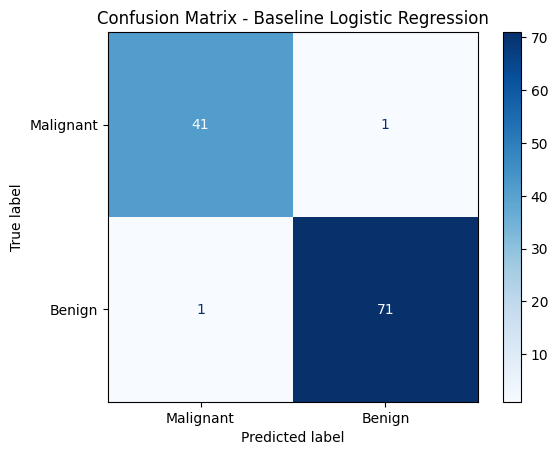


Classification Report:

              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [25]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Malignant","Benign"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Baseline Logistic Regression")
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Malignant","Benign"]))

### Confusion Matrix Interpretation

- True Positives (TP): Correctly predicted Benign cases.
- True Negatives (TN): Correctly predicted Malignant cases.
- False Positives (FP): Predicted Benign, but actually Malignant (dangerous — missed cancer treated as safe...
  wait, careful: here FP means predicted positive/benign when actually negative/malignant).
- False Negatives (FN): Predicted Malignant, but actually Benign (unnecessary alarm/treatment).

Why accuracy alone is insufficient:
- Accuracy treats all errors equally.
- In medical diagnosis, missing a malignant case (False Negative for "malignant" class) is far more costly
  than a false alarm.
- With imbalanced classes, a model can score high accuracy by just predicting the majority class, while
  completely failing on the minority (often more important) class.

### Precision, Recall & F1-Score

- Which metric matters more for medical diagnosis?
  Recall (Sensitivity) is more critical — missing a malignant case (false negative) can cost a life,
  so we want to minimize false negatives even if it means accepting more false positives.

- What happens if recall is low?
  A low recall means many actual malignant cases are being missed (classified as benign),
  which is dangerous in a medical context.

- Why is F1-score preferred for imbalanced data?
  F1-score is the harmonic mean of precision and recall, so it penalizes models that do well on one
  metric but poorly on the other. It gives a more balanced view than accuracy when classes are imbalanced.

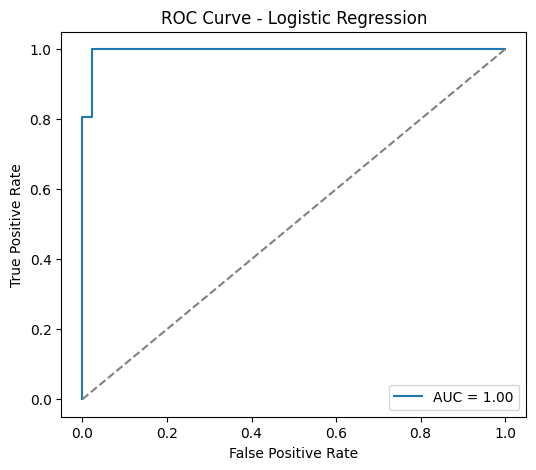

AUC Score: 0.9953703703703703


In [26]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

print("AUC Score:", auc)

Balanced Logistic Regression Classification Report:

              precision    recall  f1-score   support

   Malignant       0.91      0.98      0.94        42
      Benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



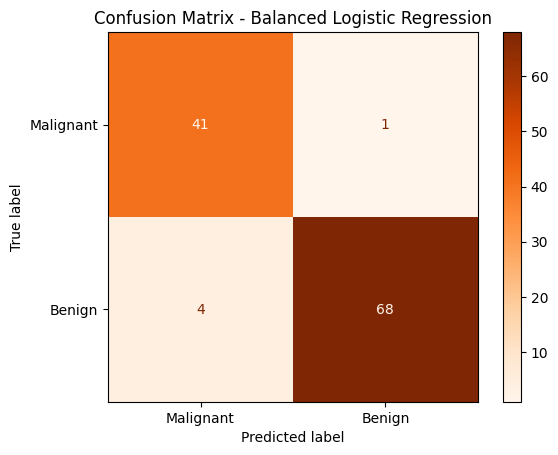

In [27]:
model_balanced = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)
model_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = model_balanced.predict(X_test_scaled)

print("Balanced Logistic Regression Classification Report:\n")
print(classification_report(y_test, y_pred_balanced, target_names=["Malignant","Benign"]))

cm_balanced = confusion_matrix(y_test, y_pred_balanced)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_balanced, display_labels=["Malignant","Benign"])
disp2.plot(cmap="Oranges")
plt.title("Confusion Matrix - Balanced Logistic Regression")
plt.show()

### Baseline vs Class-Weighted Model Comparison

Compare the classification reports from Cell 6 (baseline) and Cell 10 (balanced):
- Did recall for the malignant class improve with class_weight="balanced"?
- Did precision drop as a trade-off?
- Which model would you deploy, and why?

(Fill this in based on your actual printed numbers.)

Decision Tree Classification Report:

              precision    recall  f1-score   support

   Malignant       0.85      0.93      0.89        42
      Benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



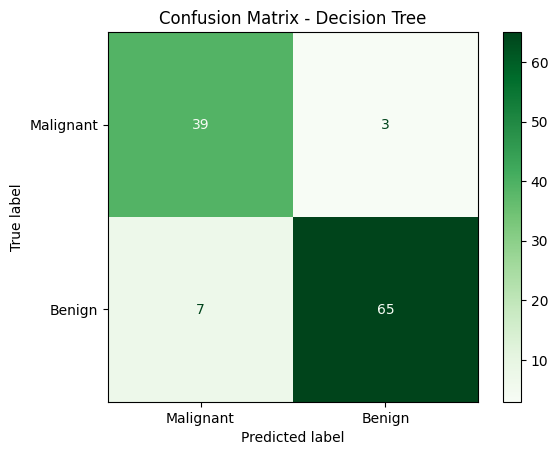

In [28]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)  # Note: trees don't require scaling

y_pred_tree = tree.predict(X_test)

print("Decision Tree Classification Report:\n")
print(classification_report(y_test, y_pred_tree, target_names=["Malignant","Benign"]))

cm_tree = confusion_matrix(y_test, y_pred_tree)
disp3 = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=["Malignant","Benign"])
disp3.plot(cmap="Greens")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

### Logistic Regression vs Decision Tree

- Stability: Logistic Regression tends to be more stable across different train/test splits since it's a
  simpler linear model with fewer degrees of freedom.
- Interpretability: Decision Tree is more directly interpretable (can trace exact decision path),
  while Logistic Regression coefficients require understanding of log-odds.
- Overfitting behavior: Decision Tree (unconstrained, no max_depth) is more prone to overfitting the
  training data compared to Logistic Regression, which is regularized by default.

Final Model Decision: Based on the metrics above (F1-score, recall, AUC), state which model you select
for deployment and justify with the specific numbers you obtained.

In [29]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring="f1"
)
grid.fit(X_train_scaled, y_train)

print("Best Params:", grid.best_params_)
print("Best CV F1-score:", grid.best_score_)

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)
print("\nTuned Model Classification Report:\n")
print(classification_report(y_test, y_pred_best, target_names=["Malignant","Benign"]))

Best Params: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1-score: 0.984524686809138

Tuned Model Classification Report:

              precision    recall  f1-score   support

   Malignant       0.98      0.95      0.96        42
      Benign       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

